# 01 — EDA: Food-delivery ETA dataset

Source: `gauravmalik26/food-delivery-dataset` (Kaggle), `train.csv` only (its `test.csv` has no target).
Pipeline: `src/data/download.py` → `src/data/clean.py` → `src/data/features.py`.

Goals of this notebook:
1. Understand the target and the main drivers.
2. Check the chronological split.
3. **Audit how real the data is** — what we can and can't claim in an interview.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt

BLUE, ORANGE, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "xtick.color": MUTED,
    "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": INK, "font.size": 9,
})

df = pd.read_parquet(ROOT / "data/processed/features.parquet")
raw = pd.read_csv(ROOT / "data/raw/train.csv", dtype=str)
print(f"raw rows {len(raw):,}  ->  clean rows {len(df):,}")
df.head()

raw rows 45,593  ->  clean rows 41,953


,order_id,rider_id,rider_age,rider_rating,rest_lat,rest_lon,cust_lat,cust_lon,order_date,weather,...,minute_of_day,day_of_week,is_weekend,rush_window,is_rush_hour,traffic_level,weather_bucket,distance_bucket,split,geo_cluster
0,0xd300,KOCRES05DEL03,39.0,4.6,9.970717,76.285447,10.030717,76.345447,2022-02-11,windy,...,0,4,0,off_peak,0,0.0,mild,6-10km,train,3
1,0xc614,DEHRES04DEL03,36.0,4.9,30.340722,78.060221,30.370722,78.090221,2022-02-11,sunny,...,0,4,0,off_peak,0,0.0,clear,3-6km,train,16
2,0xd152,BHPRES15DEL03,38.0,4.8,23.234249,77.434007,23.294249,77.494007,2022-02-11,fog,...,0,4,0,off_peak,0,0.0,severe,6-10km,train,5
3,0xc401,LUDHRES11DEL02,25.0,4.6,30.893081,75.821495,30.943081,75.871495,2022-02-11,sandstorms,...,0,4,0,off_peak,0,0.0,severe,6-10km,train,11
4,0xceea,LUDHRES18DEL02,33.0,4.9,30.890184,75.829615,30.910184,75.849615,2022-02-11,sunny,...,490,4,0,off_peak,0,0.0,clear,0-3km,train,11


## 1. Target: delivery time (minutes)

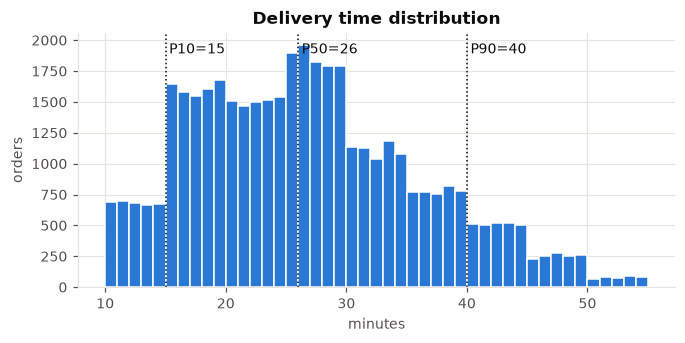

count      41953.0
mean     26.311539
std       9.380753
min           10.0
25%           19.0
50%           26.0
75%           32.0
max           54.0
Name: eta_min, dtype: Float64

In [2]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(df["eta_min"].astype(float), bins=range(10, 56), color=BLUE, edgecolor="white", linewidth=1)
for q, lab in [(0.1, "P10"), (0.5, "P50"), (0.9, "P90")]:
    v = df["eta_min"].quantile(q); ax.axvline(v, color=INK, lw=1, ls=":")
    ax.text(v + 0.3, ax.get_ylim()[1] * 0.92, f"{lab}={v:.0f}", color=INK)
ax.set(title="Delivery time distribution", xlabel="minutes", ylabel="orders")
plt.show()
df["eta_min"].describe()

Range is a tight 10–54 min with hard edges at both ends: a sign of a generated/clipped target.
The marginal P10–P90 spread is ~24 min: that's the interval width a **no-feature** model would give. Our quantile models need to beat it.

## 2. Main drivers (train split only, to avoid peeking at test)

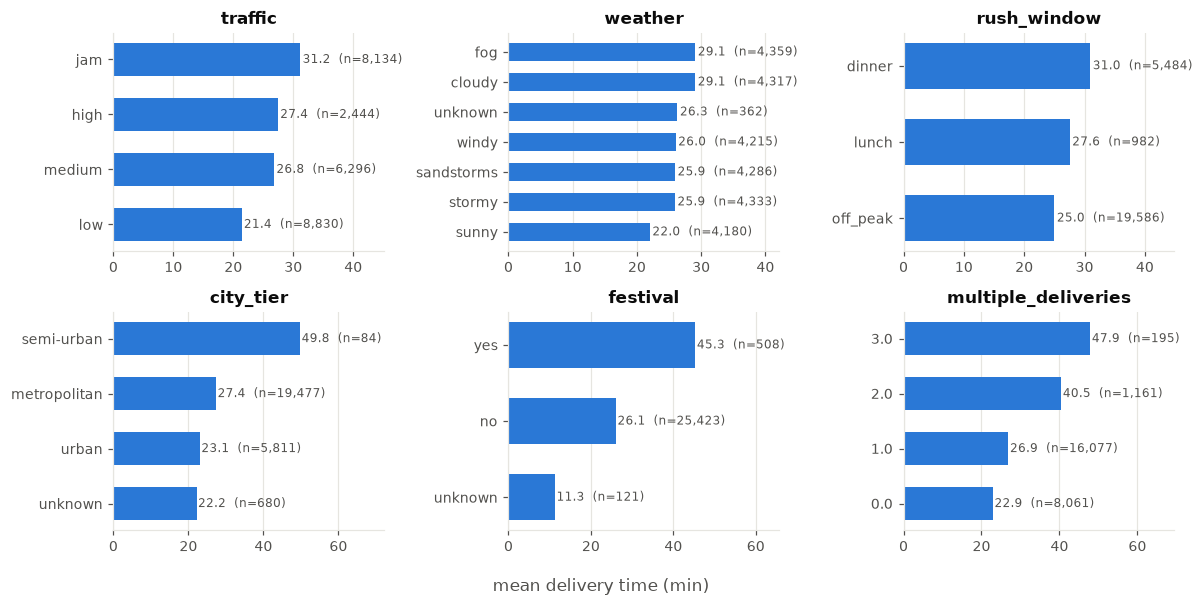

In [3]:
tr = df[df["split"] == "train"]
drivers = ["traffic", "weather", "rush_window", "city_tier", "festival", "multiple_deliveries"]
fig, axes = plt.subplots(2, 3, figsize=(11, 5.5))
for ax, c in zip(axes.flat, drivers):
    g = tr.groupby(c, observed=True)["eta_min"].agg(["mean", "size"]).sort_values("mean")
    bars = ax.barh(g.index.astype(str), g["mean"], color=BLUE, height=0.6)
    for b, (m, n) in zip(bars, g.itertuples(index=False)):
        ax.text(b.get_width() + 0.4, b.get_y() + b.get_height() / 2, f"{m:.1f}  (n={n:,})", va="center", color=MUTED, fontsize=8)
    ax.set_title(c); ax.set_xlim(0, g["mean"].max() * 1.45); ax.grid(axis="y", visible=False)
fig.supxlabel("mean delivery time (min)", color=MUTED)
plt.tight_layout(); plt.show()

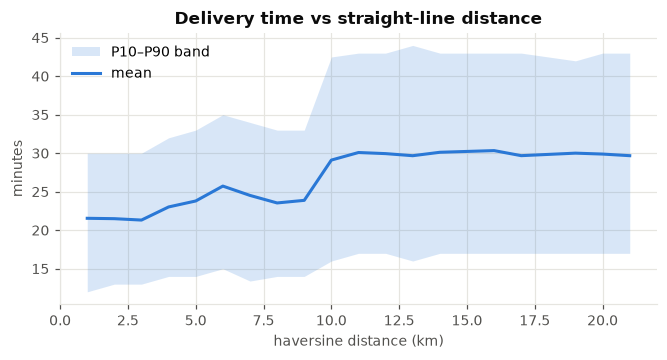

Spearman(distance, eta) = 0.324


In [4]:
fig, ax = plt.subplots(figsize=(7, 3.2))
g = tr.groupby(tr["distance_km"].round(0))["eta_min"].agg(["mean", lambda s: s.quantile(.1), lambda s: s.quantile(.9)])
g.columns = ["mean", "p10", "p90"]
ax.fill_between(g.index, g["p10"], g["p90"], color=BLUE, alpha=0.18, lw=0, label="P10–P90 band")
ax.plot(g.index, g["mean"], color=BLUE, lw=2, label="mean")
ax.set(title="Delivery time vs straight-line distance", xlabel="haversine distance (km)", ylabel="minutes")
ax.legend(frameon=False); plt.show()
print("Spearman(distance, eta) =", round(tr["distance_km"].corr(tr["eta_min"].astype(float), method="spearman"), 3))

**Read:** the distance curve is a *step*: flat ~22 min up to ~9 km, a jump at 10 km, flat again after. Real deliveries scale smoothly with distance, so this is another generator artefact (a distance-bucket rule).

Traffic, festival, multiple deliveries and weather shift the mean by 5–20 min; distance matters but the P10–P90 band at a fixed distance stays ~20 min wide — most variance is *not* explained by distance. That residual spread is exactly why an interval is more honest than a point estimate.

Note `semi-urban` (n≈100 in train) and `festival=yes` (n≈500) are **small, extreme segments**: expect poor coverage there.

## 3. Orders over time & the chronological split

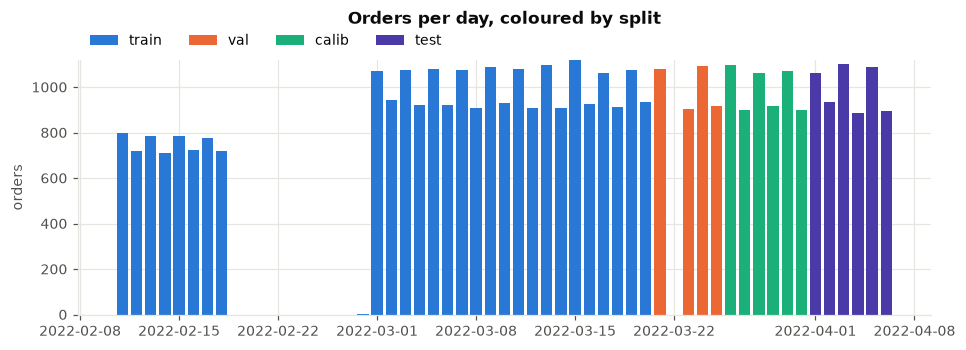

,min,max,size
split,,,
train,2022-02-11,2022-03-20 23:55:00,26052
val,2022-03-21,2022-03-25 23:55:00,3991
calib,2022-03-26,2022-03-31 23:55:00,5945
test,2022-04-01,2022-04-06 23:55:00,5965


In [5]:
daily = df.groupby([df["order_ts"].dt.normalize(), "split"]).size().unstack(fill_value=0)[["train", "val", "calib", "test"]]
fig, ax = plt.subplots(figsize=(10, 3))
bottom = np.zeros(len(daily))
colors = {"train": BLUE, "val": ORANGE, "calib": "#1baf7a", "test": "#4a3aa7"}
for s in daily.columns:
    ax.bar(daily.index, daily[s], bottom=bottom, color=colors[s], width=0.8, label=s)
    bottom += daily[s].to_numpy()
ax.set_title("Orders per day, coloured by split", pad=24); ax.set_ylabel("orders")
ax.legend(frameon=False, ncol=4, loc="lower left", bbox_to_anchor=(0, 1.0))
plt.show()
df.groupby("split")["order_ts"].agg(["min", "max", "size"]).loc[["train", "val", "calib", "test"]]

Observations:
* There's a **gap Feb 19–Feb 28** and **Mar 22 is missing** — the data is not a continuous log.
* Volume alternates ~1,070 / ~910 on odd/even days with almost no variance: not a real demand curve.
* Split is by whole days: train → val → calib → test, no overlap. The calibration window (Mar 26–31) sits
  right before test (Apr 1–6), so conformal calibration is as close to "recent" as possible.

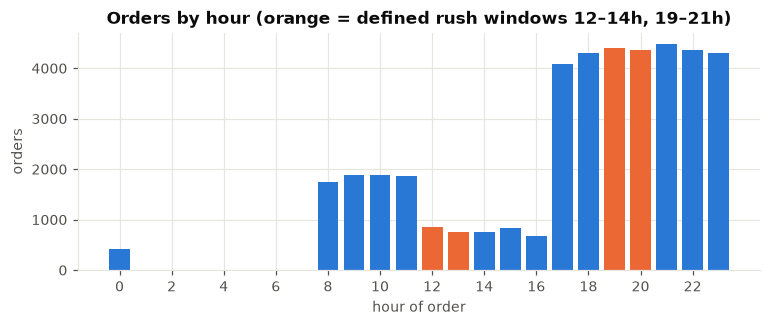

In [6]:
fig, ax = plt.subplots(figsize=(8, 2.8))
h = df["hour"].value_counts().sort_index().reindex(range(24), fill_value=0)
ax.bar(h.index, h.values, color=[ORANGE if (12 <= i < 14 or 19 <= i < 21) else BLUE for i in h.index], width=0.8)
ax.set(title="Orders by hour (orange = defined rush windows 12–14h, 19–21h)", xlabel="hour of order", ylabel="orders", xticks=range(0, 24, 2))
plt.show()

No orders between 01:00 and 07:59 and an evening plateau 17–23h. Our rush windows (12–14h, 19–21h) are a domain
prior for Indian food delivery; in this data the **evening block is busy from 17h**, so `hour` / `minute_of_day` are also
fed to the model rather than relying on the binary flag alone.

## 4. Data-authenticity audit (read before any interview)

In [7]:
checks = {}
dlat = (df["cust_lat"] - df["rest_lat"]).round(4); dlon = (df["cust_lon"] - df["rest_lon"]).round(4)
checks["customer = restaurant + (k*0.01, k*0.01) for every row"] = bool((dlat == dlon).all())
checks["distinct lat/lon offsets"] = sorted(dlat.unique().tolist())
checks["unique restaurant locations"] = df[["rest_lat", "rest_lon"]].drop_duplicates().shape[0]
checks["bearing range (deg)"] = (round(df["bearing_deg"].min(), 1), round(df["bearing_deg"].max(), 1))
checks["prep time values (min)"] = sorted(df["prep_min"].dropna().unique().tolist())
checks["weather shares (6 classes)"] = df["weather"].value_counts(normalize=True).round(3).to_dict()
checks["order-type shares"] = df["order_type"].value_counts(normalize=True).round(3).to_dict()
checks["Spearman(prep_min, eta)"] = round(df["prep_min"].corr(df["eta_min"].astype(float), method="spearman"), 3)
for k, v in checks.items(): print(f"- {k}: {v}")

- customer = restaurant + (k*0.01, k*0.01) for every row: True
- distinct lat/lon offsets: [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.11, 0.13, 0.14]
- unique restaurant locations: 388
- bearing range (deg): (np.float64(40.6), np.float64(44.6))
- prep time values (min): [5.0, 10.0, 15.0]
- weather shares (6 classes): {'fog': 0.167, 'stormy': 0.166, 'cloudy': 0.165, 'sandstorms': 0.165, 'windy': 0.163, 'sunny': 0.16, 'unknown': 0.014}
- order-type shares: {'snack': 0.253, 'meal': 0.251, 'drinks': 0.249, 'buffet': 0.247}
- Spearman(prep_min, eta): -0.008


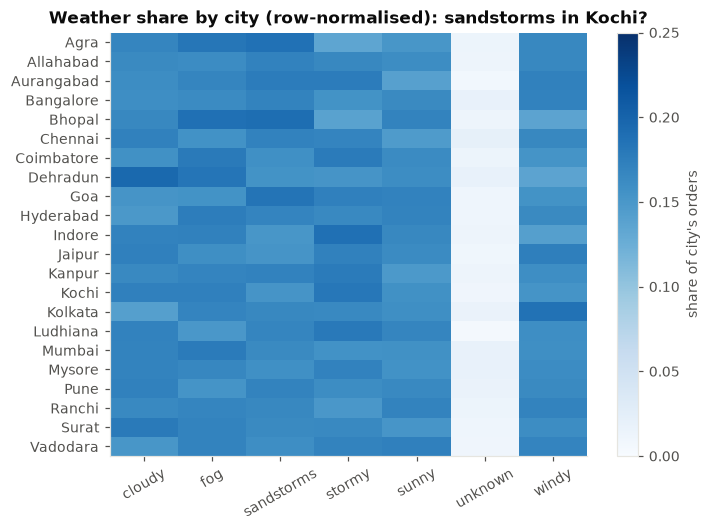

In [8]:
ct = pd.crosstab(tr["city"], tr["weather"], normalize="index")
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(ct.values, cmap="Blues", vmin=0, vmax=0.25, aspect="auto")
ax.set_xticks(range(ct.shape[1]), ct.columns, rotation=30); ax.set_yticks(range(ct.shape[0]), ct.index)
ax.grid(False); ax.set_title("Weather share by city (row-normalised): sandstorms in Kochi?")
fig.colorbar(im, ax=ax, label="share of city's orders"); plt.show()

### Verdict — what this means for the project

| Finding | Implication | What to say in an interview |
|---|---|---|
| Customer point = restaurant + identical lat/lon offset, 12 values | Geography is synthetic; distance has ~12 levels per city, bearing is constant | "Distance features are engineered properly, but the dataset's customer locations are synthetic offsets, so geospatial signal is capped. On real data I'd add road distance from a routing engine." |
| Weather ~uniform over 6 classes in *every* city (incl. sandstorms in coastal cities) | Weather is a generated label, not real meteorology | "Weather has a strong effect in this data, but it's simulated — I wouldn't claim weather modelling skill from it." |
| Prep time ∈ {5, 10, 15}, uncorrelated with ETA | No signal; also leakage-by-timing at order time | Excluded from the at-order model; available in `FEATURES_AT_PICKUP`. |
| Target clipped to 10–54 min | Tails are truncated → real-world P90s would be wider | Coverage results are optimistic vs. production. |
| Rider ID encodes city | Real categorical `city` is recoverable without clustering | Derived city from ID; KMeans `geo_cluster` kept as the lat/long-based alternative. |

The modelling methodology (quantile regression → conformal calibration → segmented coverage) transfers unchanged to real
data. The *numbers* are a property of this semi-synthetic dataset and should be presented that way.